# TCGA Expression Processing (Xena)

This notebook constructs a **gene × cancer expression matrix** from TCGA RNA-seq data.
The pipeline includes:
- Tumor vs normal sample separation
- Cancer-level aggregation
- Fold-change computation (tumor vs normal)
- Gene symbol normalization and merging

---

## Mathematical Overview

Let:
- $E_{g,s}$ = expression of gene $g$ in sample $s$
- $\mathcal{S}_c^{(T)}$ = tumor samples for cancer $c$
- $\mathcal{S}_c^{(N)}$ = normal samples for cancer $c$

Then:

**Tumor mean expression**
\begin{equation}
\bar{E}_g^{(T,c)} = \frac{1}{|\mathcal{S}_c^{(T)}|} \sum_{s \in \mathcal{S}_c^{(T)}} E_{g,s}
\tag{1}
\end{equation}

**Normal mean expression**
\begin{equation}
\bar{E}_g^{(N,c)} = \frac{1}{|\mathcal{S}_c^{(N)}|} \sum_{s \in \mathcal{S}_c^{(N)}} E_{g,s}
\tag{2}
\end{equation}

**Fold-change (log scale)**
\begin{equation}
FC(g,c) = \log_2 \frac{\bar{E}_g^{(T,c)} + \epsilon}{\bar{E}_g^{(N,c)} + \epsilon}
\tag{3}
\end{equation}

where $\epsilon$ prevents division by zero.

In [9]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

SAVE_DIR = "data/tcga"
os.makedirs(SAVE_DIR, exist_ok=True)

EXPR_FILE = "../data/_xena/EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena"
PHENO_FILE = "../data/_phenotype/TCGA_phenotype_denseDataOnlyDownload.tsv.gz"


COLORS = {
    0: '#0077B6',   1: '#0000FF',   2: '#00B4D8',   3: '#48EAC4',
    4: '#F1C0E8',   5: '#B9FBC0',   6: '#32CD32',   7: '#BEE1E6',
    8: '#8A2BE2',   9: '#E377C2',  10: '#8EECF5',  11: '#A3C4F3',
    12: '#FFB347', 13: '#FFD700',  14: '#FF69B4',  15: '#CD5C5C',
    16: '#7FFFD4', 17: '#FF7F50',  18: '#C71585',  19: '#20B2AA',
    20: '#6A5ACD', 21: '#40E0D0',  22: '#FF8C00',  23: '#DC143C',
    24: '#9ACD32',
    25: '#1F77B4', 26: '#FF1493', 27: '#2E8B57', 28: '#D2691E',
    29: '#9932CC', 30: '#00CED1', 31: '#FF4500', 32: '#708090'
}


disease_to_tcga = {
    "adrenocortical carcinoma": "ACC",
    "bladder urothelial carcinoma": "BLCA",
    "breast invasive carcinoma": "BRCA",
    "cervical squamous cell carcinoma and endocervical adenocarcinoma": "CESC",
    "cholangiocarcinoma": "CHOL",
    "colon adenocarcinoma": "COAD",
    "rectum adenocarcinoma": "READ",
    "diffuse large B-cell lymphoma": "DLBC",
    "esophageal carcinoma": "ESCA",
    "glioblastoma multiforme": "GBM",
    "head and neck squamous cell carcinoma": "HNSC",
    "kidney chromophobe": "KICH",
    "kidney renal clear cell carcinoma": "KIRC",
    "kidney renal papillary cell carcinoma": "KIRP",
    "acute myeloid leukemia": "LAML",
    "brain lower grade glioma": "LGG",
    "liver hepatocellular carcinoma": "LIHC",
    "lung adenocarcinoma": "LUAD",
    "lung squamous cell carcinoma": "LUSC",
    "mesothelioma": "MESO",
    "ovarian serous cystadenocarcinoma": "OV",
    "pancreatic adenocarcinoma": "PAAD",
    "pheochromocytoma and paraganglioma": "PCPG",
    "prostate adenocarcinoma": "PRAD",
    "sarcoma": "SARC",
    "skin cutaneous melanoma": "SKCM",
    "stomach adenocarcinoma": "STAD",
    "testicular germ cell tumors": "TGCT",
    "thyroid carcinoma": "THCA",
    "thymoma": "THYM",
    "uterine corpus endometrial carcinoma": "UCEC",
    "uterine carcinosarcoma": "UCS",
    "uveal melanoma": "UVM"
}

len(set(disease_to_tcga.values()))

33

## Gene Cleaning and Standardization

TCGA/Xena gene identifiers may include:
- Ensembl IDs with version suffix (e.g., `ENSG000001.5`)
- Numeric artifacts or missing values

We clean genes by:
- Removing version suffix
- Filtering invalid symbols
- Converting to uppercase

This ensures consistent merging across omics layers.

In [10]:
def clean_gene_column(df):
    df["gene"] = df["gene"].astype(str).str.split(".").str[0]
    df = df[~df["gene"].str.match(r"^\d+$")]
    df = df[df["gene"].notna()]
    df = df[df["gene"] != ""]
    df["gene"] = df["gene"].str.upper()
    return df


## Load Phenotype Data and Identify Tumor Samples

Each sample is annotated with:
- Cancer type
- Sample type (tumor vs normal)

We define:

\begin{equation}
I_{\text{tumor}}(s) =
\begin{cases}
1 & \text{if } s \text{ is tumor} \\
0 & \text{otherwise}
\end{cases}
\tag{4}
\end{equation}

This enables stratified aggregation.

In [11]:
pheno = pd.read_csv(PHENO_FILE, sep="\t", compression="gzip")
pheno.columns = pheno.columns.str.strip()

pheno["Sample"] = pheno["sample"]
pheno["_primary_disease"] = pheno["_primary_disease"].str.strip().str.lower()

# tumor vs normal
pheno["is_tumor"] = pheno["sample_type"].str.contains("tumor", case=False, na=False)

print("Total samples:", len(pheno))


Total samples: 12804


## Map Disease Names to TCGA Cancer Codes

To ensure consistency across datasets, disease labels are mapped to TCGA abbreviations:

\begin{equation}
c = f(\text{disease name})
\tag{5}
\end{equation}

Only mapped cancers are retained.

In [ ]:

len(set(disease_to_tcga.values()))

pheno["Cancer"] = pheno["_primary_disease"].map(disease_to_tcga)
pheno = pheno.dropna(subset=["Cancer"])

print("Mapped samples:", len(pheno))


Mapped samples: 9513


## Load Expression Matrix

The Xena expression matrix has:
- Rows = genes
- Columns = samples

After loading, gene cleaning is applied to ensure consistency.

In [13]:
expr = pd.read_csv(EXPR_FILE, sep="\t")
expr.rename(columns={expr.columns[0]: "gene"}, inplace=True)

expr = clean_gene_column(expr)

print("Expression shape:", expr.shape)


Expression shape: (20502, 11070)


## Align Samples Between Expression and Phenotype

Only samples present in both datasets are retained:

\begin{equation}
\mathcal{S}_{\text{common}} = \mathcal{S}_{expr} \cap \mathcal{S}_{pheno}
\tag{6}
\end{equation}

This ensures valid downstream aggregation.

In [14]:
common_samples = list(set(expr.columns) & set(pheno["Sample"]))

expr = expr[["gene"] + common_samples]
pheno = pheno[pheno["Sample"].isin(common_samples)]

print("Matched samples:", len(common_samples))


Matched samples: 8218


## Split Tumor and Normal Samples

We partition samples into:
- Tumor group $\mathcal{S}^{(T)}$
- Normal group $\mathcal{S}^{(N)}$

In [15]:
tumor_samples = pheno[pheno["is_tumor"] == True]
normal_samples = pheno[pheno["is_tumor"] == False]

print("Tumor:", len(tumor_samples))
print("Normal:", len(normal_samples))


Tumor: 7106
Normal: 1112


## Aggregate Expression by Cancer Type

For each cancer $c$, we compute:

\begin{equation}
\bar{E}_g^{(c)} = \frac{1}{|\mathcal{S}_c|} \sum_{s \in \mathcal{S}_c} E_{g,s}
\tag{7}
\end{equation}

This produces a **gene × cancer matrix**.

In [16]:
def aggregate_expression(sample_df):
    cancer_dict = {}

    for sample in tqdm(sample_df["Sample"], desc="Processing samples"):
        cancer = sample_df.loc[sample_df["Sample"] == sample, "Cancer"].values
        if len(cancer) == 0:
            continue

        cancer = cancer[0]

        if cancer not in cancer_dict:
            cancer_dict[cancer] = []

        cancer_dict[cancer].append(expr[sample].values)

    cancers = sorted(cancer_dict.keys())

    matrix = np.array([
        np.mean(cancer_dict[c], axis=0)
        for c in cancers
    ]).T

    return pd.DataFrame(matrix, columns=cancers)

tumor_df = aggregate_expression(tumor_samples)
normal_df = aggregate_expression(normal_samples)

genes = expr["gene"].values
tumor_df.insert(0, "gene", genes)
normal_df.insert(0, "gene", genes)


Processing samples: 100%|██████████| 1112/1112 [00:00<00:00, 5257.28it/s]


## Compute Tumor vs Normal Fold-Change

The log fold-change is computed as:

\begin{equation}
FC(g,c) = \log_2 \frac{\bar{E}_g^{(T,c)} + \epsilon}{\bar{E}_g^{(N,c)} + \epsilon}
\tag{3}
\end{equation}

If normal samples are unavailable for a cancer, a global normal baseline is used.

In [17]:
fc_df = tumor_df.copy()

for c in tumor_df.columns[1:]:
    if c in normal_df.columns:
        fc_df[c] = np.log2((tumor_df[c] + 1e-6) / (normal_df[c] + 1e-6))
    else:
        fc_df[c] = np.log2((tumor_df[c] + 1e-6) / (normal_df.iloc[:,1:].mean(axis=1) + 1e-6))

fc_df.replace([np.inf, -np.inf], 0, inplace=True)
fc_df.fillna(0, inplace=True)

print("Fold-change shape:", fc_df.shape)


Fold-change shape: (20502, 24)


/home/eric_karma/anaconda3/envs/reactome_gnn/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/eric_karma/anaconda3/envs/reactome_gnn/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/eric_karma/anaconda3/envs/reactome_gnn/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/eric_karma/anaconda3/envs/reactome_gnn/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/eric_karma/anaconda3/envs/reactome_gnn/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log2
  result = getattr

## Merge Duplicate Genes

Some genes appear multiple times due to:
- Transcript variants
- Annotation redundancy

We merge duplicates via averaging:

\begin{equation}
FC_{\text{merged}}(g,c) = \frac{1}{k} \sum_{i=1}^{k} FC_i(g,c)
\tag{8}
\end{equation}

In [18]:
fc_df = fc_df.groupby("gene", as_index=False).mean()

print("After gene merge:", fc_df.shape)


After gene merge: (20501, 24)


## Save Final Expression Features

The final output is a:

**gene × cancer matrix**

where each value represents tumor vs normal fold-change.

In [ ]:
out_file = os.path.join(SAVE_DIR, "expression_features.csv")
fc_df.to_csv(out_file, index=False)

print("Saved:", out_file)


Saved: data/tcga/expression_foldchange.csv


## Distribution of Gene Expression Fold-Change Across Cancers

To understand the global behavior of differential expression, we visualize
the distribution of fold-change values across cancers using boxplots.

---

### Mathematical Interpretation

For each cancer type $c$, we consider the distribution:

\begin{equation}
\mathcal{D}_c = \{ FC(g,c) \mid g \in \mathcal{G} \}
\tag{9}
\end{equation}

where $FC(g,c)$ is the log fold-change:

\begin{equation}
FC(g,c) = \log_2 \frac{\bar{E}_g^{(T,c)} + \epsilon}{\bar{E}_g^{(N,c)} + \epsilon}
\tag{10}
\end{equation}

The boxplot summarizes:
- Median (central tendency)
- Interquartile range (IQR)
- Outliers (extreme gene dysregulation)

---

### Biological Interpretation

- **Wide distributions** → high transcriptional heterogeneity
- **Shifted median (>0)** → global upregulation
- **Shifted median (<0)** → global downregulation
- **Long tails** → presence of strongly dysregulated driver genes

### Colored Boxplot per Cancer

Each cancer is assigned a consistent color from a predefined palette:

\begin{equation}
c \rightarrow \text{color}_c
\tag{11}
\end{equation}

This ensures consistency across PCA, UMAP, and downstream visualizations.

/tmp/ipykernel_16612/1038132515.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


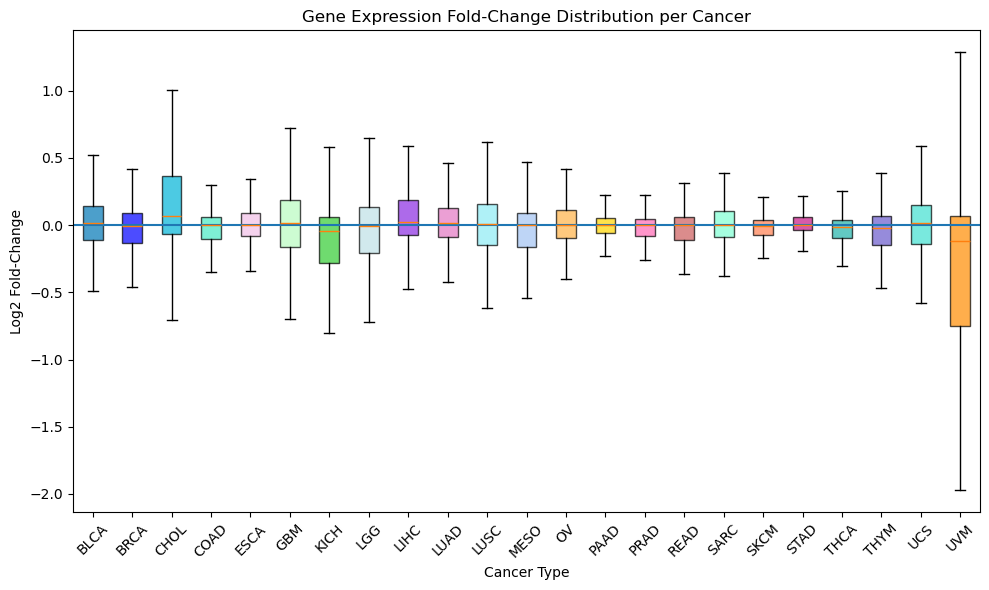

In [21]:

import matplotlib.pyplot as plt

fc_values = fc_df.set_index("gene")

cancers = list(fc_values.columns)

color_map = {
    c: COLORS[i % len(COLORS)]
    for i, c in enumerate(cancers)
}

plot_colors = [color_map[c] for c in cancers]

plt.figure(figsize=(10, 6))

bp = plt.boxplot(
    [fc_values[c] for c in cancers],
    labels=cancers,
    patch_artist=True,
    showfliers=False
)

# apply colors
for patch, color in zip(bp["boxes"], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.axhline(0)

plt.title("Gene Expression Fold-Change Distribution per Cancer")
plt.xlabel("Cancer Type")
plt.ylabel("Log2 Fold-Change")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Density-Aware Visualization (Violin Plot)

Violin plots show the full distribution shape which estimates:

\begin{equation}
p(FC(g,c))
\tag{12}
\end{equation}

This reveals multimodality and skewness not visible in boxplots.

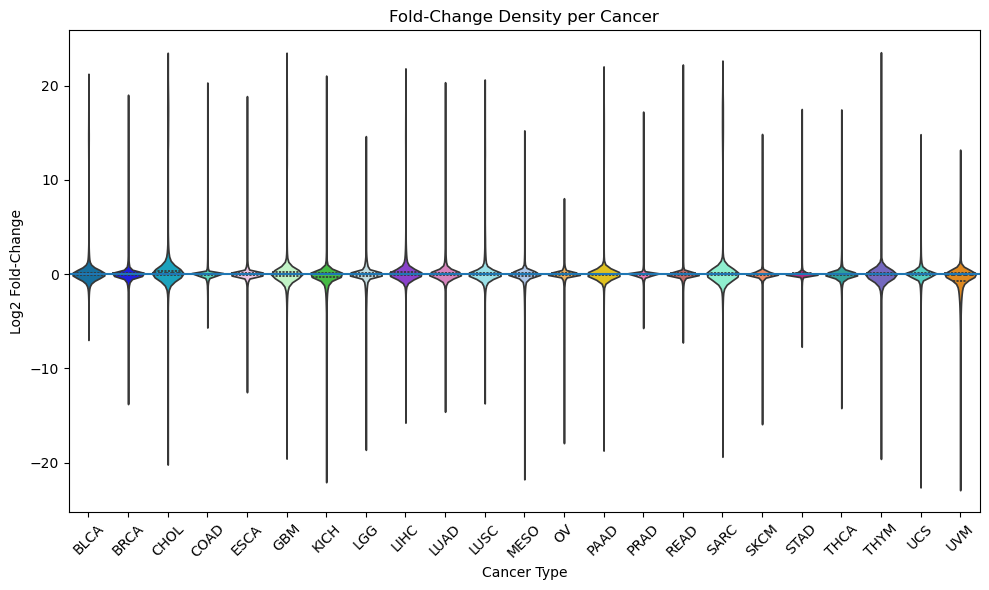

In [22]:
# %%
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=fc_values,
    palette=plot_colors,
    inner="quartile"
)

plt.axhline(0)

plt.title("Fold-Change Density per Cancer")
plt.xlabel("Cancer Type")
plt.ylabel("Log2 Fold-Change")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# %%
stats = pd.DataFrame({
    "mean": fc_values.mean(),
    "std": fc_values.std(),
    "median": fc_values.median()
})

print(stats)

          mean       std    median
BLCA  0.652743  3.085119  0.012924
BRCA  0.142745  1.558626 -0.003899
CHOL  1.199802  4.261574  0.065432
COAD -0.046080  0.595470  0.000000
ESCA  0.041369  0.962538  0.000000
GBM   0.709921  3.610649  0.015152
KICH -0.067735  2.594537 -0.040238
LGG  -0.174027  1.290973 -0.004010
LIHC  0.733021  3.036075  0.025759
LUAD  0.489104  2.437685  0.015617
LUSC  0.470760  2.466830  0.009614
MESO -0.322107  1.779169 -0.001953
OV   -0.051041  0.750094  0.000000
PAAD  0.534301  3.092040 -0.002541
PRAD -0.010351  0.671829  0.000000
READ -0.014713  1.009895  0.000000
SARC  1.124172  4.348617  0.004331
SKCM -0.071195  1.221110 -0.004078
STAD  0.014083  0.369084  0.000000
THCA  0.203637  1.852172 -0.013674
THYM  0.767902  3.878932 -0.017886
UCS  -0.159266  1.793333  0.012689
UVM  -1.009584  2.936339 -0.115508


# Dual-Level Cancer Embedding Pipeline
This notebook constructs a multi-scale representation of cancer biology:
- Sample-level embeddings → capture tumor heterogeneity
- Cancer-level centroids → capture global cancer structure
- Integrated visualization → PCA, UMAP, lineage, similarity
The pipeline bridges individual tumor variation and population-level cancer organization.

In [24]:
X_sample = expr.set_index("gene").T

tumor_ids = tumor_samples["Sample"].values
X_sample = X_sample.loc[X_sample.index.intersection(tumor_ids)]

print("Sample-level matrix:", X_sample.shape)

Sample-level matrix: (7106, 20502)


## 2. Align Samples to Cancer Types
Each sample is mapped to its cancer type using phenotype metadata.
Since TCGA barcodes may differ in length, we use the first 12 characters:
[
s_{\text{short}} = s[0:12]
]
This ensures consistent alignment between expression and phenotype data.

In [25]:
def short_barcode(s):
    return s[:12]

sample_to_cancer = {
short_barcode(s): c
for s, c in zip(pheno["Sample"], pheno["Cancer"])
}

cancer_labels = pd.Series(
[sample_to_cancer.get(short_barcode(s), "Unknown") for s in X_sample.index],
index=X_sample.index
)

mask = cancer_labels != "Unknown"
X_sample = X_sample.loc[mask]
cancer_labels = cancer_labels.loc[mask]

print("Samples after alignment:", X_sample.shape)

Samples after alignment: (7106, 20502)


## 3. Feature Normalization and PCA
We standardize features to zero mean and unit variance:
[
X' = \frac{X - \mu}{\sigma}
]
Then apply PCA to reduce dimensionality:
[
Z = X' W
]
where 
𝑊
W contains the principal components.
PCA captures dominant axes of variation across tumors.

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use ONE variable consistently
X_sample = X_sample.replace([np.inf, -np.inf], np.nan)

print("NaN count before:", X_sample.isna().sum().sum())

X_sample = X_sample.fillna(0)

assert not X_sample.isna().any().any(), "Still NaNs present!"

print("Final shape:", X_sample.shape)

# Scale
X_scaled = StandardScaler().fit_transform(X_sample)

# PCA
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)



X_scaled = StandardScaler().fit_transform(X_sample)

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)

NaN count before: 2133415
Final shape: (7106, 20502)
PCA shape: (7106, 50)
PCA shape: (7106, 50)


## 4. Nonlinear Embedding with UMAP
We apply UMAP to capture nonlinear structure in the data.
UMAP preserves local relationships by constructing a fuzzy topological graph:
[
\text{UMAP}: \mathbb{R}^d \rightarrow \mathbb{R}^2
]
This reveals clusters corresponding to cancer types and subtypes.

In [27]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.3)
X_umap = reducer.fit_transform(X_pca)

print("UMAP shape:", X_umap.shape)

UMAP shape: (7106, 2)


## 5. Cancer-Level Centroid Construction

Each cancer type is represented by the centroid (mean vector) of its samples:

\[
\mathbf{c}_k = \frac{1}{|\mathcal{S}_k|} \sum_{i \in \mathcal{S}_k} \mathbf{x}_i
\]

where:

- \(\mathcal{S}_k\): set of samples belonging to cancer type \(k\)  
- \(\mathbf{x}_i\): feature vector of sample \(i\)  

This provides a **global representation** of each cancer type by averaging all its samples in feature space.

In [28]:
import numpy as np

centroids = {}
for c in cancer_labels.unique():
    mask = cancer_labels == c
centroids[c] = X_umap[mask].mean(axis=0)

centroid_labels = list(centroids.keys())
centroid_matrix = np.vstack(list(centroids.values()))

print("Centroids:", centroid_matrix.shape)

Centroids: (1, 2)


## 6. Color Mapping for Visualization
Each cancer type is assigned a distinct color for visualization consistency across plots.
This ensures interpretability across PCA, UMAP, and clustering visualizations.

In [29]:
cancers = sorted(cancer_labels.unique())

color_map = {
c: COLORS[i % len(COLORS)]
for i, c in enumerate(cancers)
}

sample_colors = cancer_labels.map(color_map)
centroid_colors = [color_map[c] for c in centroid_labels]

## 7. Visualization
Figure panel:
- (A) PCA → global variance structure
- (B) UMAP → nonlinear clustering + centroids
- (C) Distance heatmap → cancer similarity
This provides a multi-scale view of cancer organization.

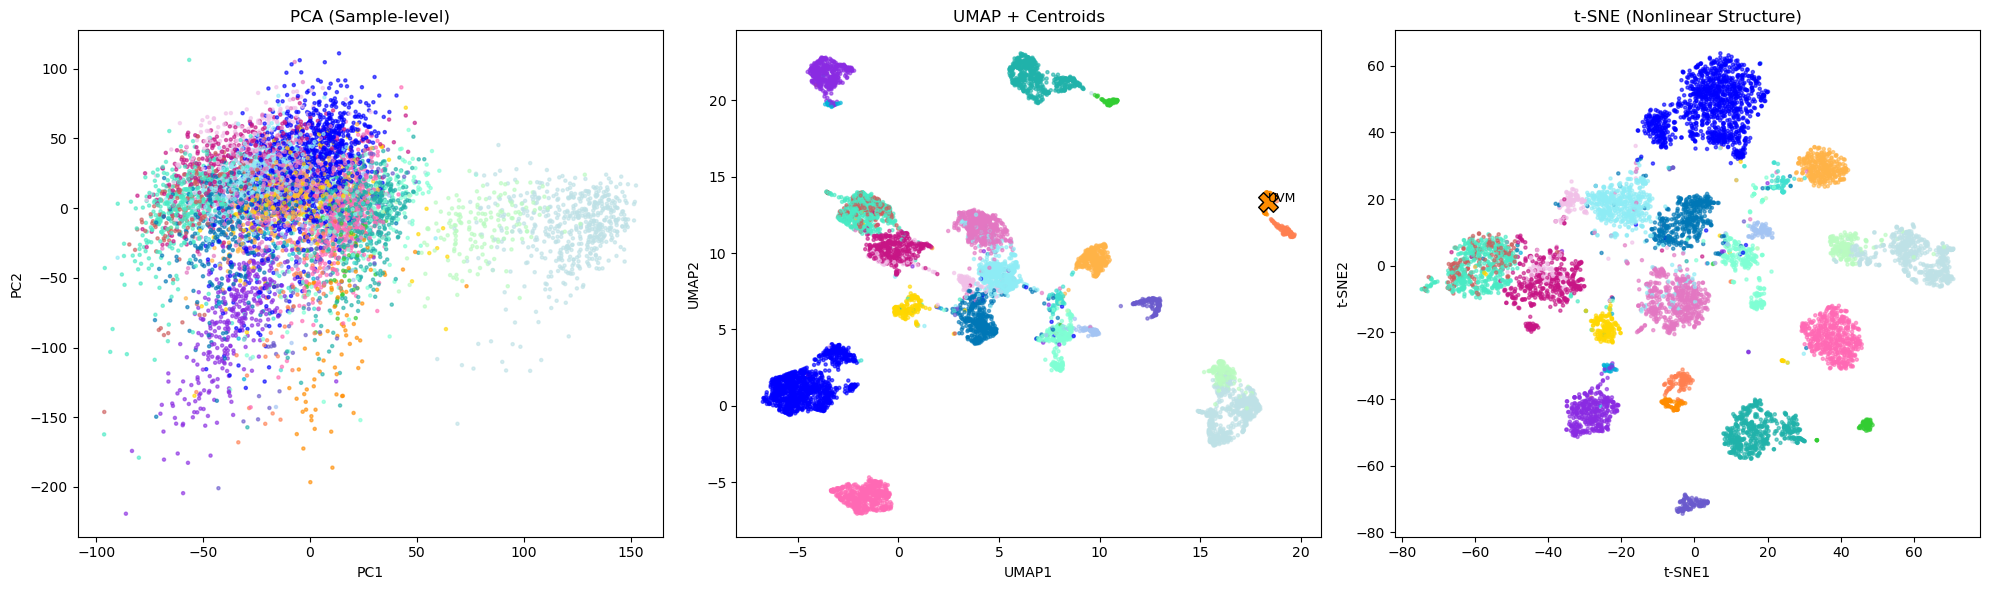

In [30]:
from sklearn.manifold import TSNE

# Use SAME input as PCA/UMAP (important!)
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
).fit_transform(X_scaled)  # use scaled data

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---------------------------
# PCA
# ---------------------------
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=sample_colors,
    s=5,
    alpha=0.6
)
axes[0].set_title("PCA (Sample-level)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")


# ---------------------------
# UMAP + Centroids
# ---------------------------
axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=sample_colors,
    s=5,
    alpha=0.6
)

axes[1].scatter(
    centroid_matrix[:, 0],
    centroid_matrix[:, 1],
    c=centroid_colors,
    s=200,
    marker='X',
    edgecolor='black'
)

for i, c in enumerate(centroid_labels):
    axes[1].text(
        centroid_matrix[i, 0],
        centroid_matrix[i, 1],
        c,
        fontsize=9
    )

axes[1].set_title("UMAP + Centroids")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")


# ---------------------------
# t-SNE (replacing similarity)
# ---------------------------
axes[2].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=sample_colors,
    s=5,
    alpha=0.6
)

axes[2].set_title("t-SNE (Nonlinear Structure)")
axes[2].set_xlabel("t-SNE1")
axes[2].set_ylabel("t-SNE2")


plt.tight_layout()
plt.show()

## Interpretation
This dual-level framework reveals:
### Sample-level
- Tumor heterogeneity
- Subtype structure
### Cancer-level
- Inter-cancer similarity
- Evolutionary relationships
### Integrated insight
- Centroids act as a bridge between scales
- Enables transition from patient-level data → cancer system modeling
This structure is directly extensible to:
- GNN embeddings
- Pathway evolution
- Multi-omics integration